In [1]:
#Heart Disease Prediction

In [2]:
#Problem : To predict the likelyhood of heart disease based on medical data

In [3]:
#Model development
#Three algorithms : Logistic Regression,Support Vector Classifier and Decision Tree Classifier

In [4]:
#Performance Evaluation
#Accuracy, #Precision, #Recall, #F1 Score, #AUC-ROC, #Confusion Matrix

In [5]:
#Import neccessary libraries

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC  # Support Vector Classifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#Load the dataset

In [8]:
heartds = pd.read_csv("Heart_Disease_Prediction.csv")


In [9]:
#Exploratory Data Analysis

In [10]:
heartds.shape

(270, 14)

In [11]:
heartds.head(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [12]:
heartds.tail(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
265,52,1,3,172,199,1,0,162,0,0.5,1,0,7,Absence
266,44,1,2,120,263,0,0,173,0,0.0,1,0,7,Absence
267,56,0,2,140,294,0,2,153,0,1.3,2,0,3,Absence
268,57,1,4,140,192,0,0,148,0,0.4,2,0,6,Absence
269,67,1,4,160,286,0,2,108,1,1.5,2,3,3,Presence


In [13]:
heartds.sample(5)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
207,58,1,3,105,240,0,2,154,1,0.6,2,0,7,Absence
249,60,1,4,145,282,0,2,142,1,2.8,2,2,7,Presence
56,61,1,4,138,166,0,2,125,1,3.6,2,1,3,Presence
129,60,1,4,117,230,1,0,160,1,1.4,1,2,7,Presence
26,46,0,4,138,243,0,2,152,1,0.0,2,0,3,Absence


In [14]:
heartds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [15]:
#Fields in dataset and its explanation
#270 patients 
#1. Age : Age of  patient
#2. Sex : Gender of patient ::1-Male and 0-Female
#3. Chest pain type : 4 types(1,2,3,4)
#1 - typical angina
#2 - atypical angina
#3 - non anginal pain
#4 - asymptotic
#4. BP : Blood Pressure 
#5. Cholesterol : in mg/dl
#6. FBS over 120 : Fasting Blood Sugar > mg/dl
#7. EKG results : Electrocardiographic results (0,1,2)
#8. Max HR : Maximum Heart rate achieved
#9. Exercise angina : 0 and 1, 0=No and 1=yes
#10. ST depression : ST depression induced by exercise relative to rest
#11. Slope of ST ;slope of peak exercise ST depression
#12. Number of vessels fluro : Number of major vessels coloure by fluroscopy (0,1,2,3)
#13. Thallium : Test Results 3,6,7 : 3 - Normal ,6 - Fixed defect, 7 -Reversible defect
#14. Target Field : Heart Disease : Presence or absence

In [16]:
info = ["Age",
        "1: male, 0: female",
        "Chest pain type 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic",
        "Blood Pressure",
        "Cholestoral in mg/dl",
        "fasting blood sugar > 120 mg/dl",
        "EKG electrocardiographic results (values 0,1,2)",
        " Max HR maximum heart rate achieved",
        "Exercise induced angina",
        "ST depression = ST depression induced by exercise relative to rest",
        "Slope of ST = the slope of the peak exercise ST segment",
        "number of major vessels (0-3) colored by flourosopy",
        "thallium test Results : 3 = normal; 6 = fixed defect; 7 = reversable defect"]


In [17]:
for i in range(len(info)):
    print(heartds.columns[i]+":\t\t"+info[i])

Age:		Age
Sex:		1: male, 0: female
Chest pain type:		Chest pain type 1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic
BP:		Blood Pressure
Cholesterol:		Cholestoral in mg/dl
FBS over 120:		fasting blood sugar > 120 mg/dl
EKG results:		EKG electrocardiographic results (values 0,1,2)
Max HR:		 Max HR maximum heart rate achieved
Exercise angina:		Exercise induced angina
ST depression:		ST depression = ST depression induced by exercise relative to rest
Slope of ST:		Slope of ST = the slope of the peak exercise ST segment
Number of vessels fluro:		number of major vessels (0-3) colored by flourosopy
Thallium:		thallium test Results : 3 = normal; 6 = fixed defect; 7 = reversable defect


In [18]:
#Our target field is Heart Disease

In [19]:
heartds["Heart Disease"].describe()

count         270
unique          2
top       Absence
freq          150
Name: Heart Disease, dtype: object

In [20]:
heartds['Heart Disease'].value_counts()

Absence     150
Presence    120
Name: Heart Disease, dtype: int64

In [21]:
#Describe 
heartds.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [22]:
correlation_matrix = heartds.corr(method='spearman')

In [23]:
correlation_matrix

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
Age,1.000000,-0.098542,0.120597,0.276844,0.211059,0.117920,0.128298,-0.399880,0.094830,0.257712,0.174111,0.374962,0.108891
Sex,-0.098542,1.000000,0.066653,-0.054963,-0.158326,0.042140,0.039491,-0.076223,0.180022,0.111564,0.051063,0.103746,0.382306
Chest pain type,0.120597,0.066653,1.000000,-0.001953,0.100225,-0.107783,0.110092,-0.349173,0.401879,0.211559,0.192331,0.250993,0.304878
BP,0.276844,-0.054963,-0.001953,1.000000,0.190482,0.133742,0.116558,-0.042943,0.070456,0.182700,0.107484,0.058231,0.107421
Cholesterol,0.211059,-0.158326,0.100225,0.190482,1.000000,0.032506,0.163601,-0.056473,0.104276,0.013844,-0.000694,0.154671,0.019726
FBS over 120,0.117920,0.042140,-0.107783,0.133742,0.032506,1.000000,0.053567,0.014583,-0.004107,-0.008769,0.020992,0.115877,0.046360
EKG results,0.128298,0.039491,0.110092,0.116558,0.163601,0.053567,1.000000,-0.115033,0.095038,0.110352,0.161585,0.110935,0.005381
Max HR,-0.399880,-0.076223,-0.349173,-0.042943,-0.056473,0.014583,-0.115033,1.000000,-0.394153,-0.423185,-0.427491,-0.290284,-0.269459
Exercise angina,0.094830,0.180022,0.401879,0.070456,0.104276,-0.004107,0.095038,-0.394153,1.000000,0.276431,0.271273,0.186474,0.320636
ST depression,0.257712,0.111564,0.211559,0.182700,0.013844,-0.008769,0.110352,-0.423185,0.276431,1.000000,0.625263,0.241518,0.339188


In [24]:
#Data Preprocessing

In [25]:
#1. Finding any null  or missing values

In [26]:
heartds.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [27]:
heartds.isna().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [28]:
heartds.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

In [29]:
#To find the count of males and females :::: 1 - M and 0 - F

In [30]:
heartds['Sex'].value_counts()

1    183
0     87
Name: Sex, dtype: int64

In [31]:
#To check how many patients have heartdisease

In [32]:
heartds['Heart Disease'].value_counts()

Absence     150
Presence    120
Name: Heart Disease, dtype: int64

In [33]:
#Male and Female Heart Patients count

In [34]:
male_heart_patients = heartds[(heartds['Sex'] == 1) & (heartds['Heart Disease'] == 'Presence')]
female_heart_patients = heartds[(heartds['Sex'] == 0) & (heartds['Heart Disease'] == 'Presence')]


In [35]:
countm = len(male_heart_patients)
countfm =len(female_heart_patients)

In [36]:
countm

100

In [37]:
countfm

20

In [38]:
#100 Male heart disease patients and 20 female heart disease patients

In [39]:
import matplotlib.pyplot as plt

([<matplotlib.patches.Wedge at 0x7fb9f0a96970>,
 [Text(-0.1910130855889933, 1.083288512416601, 'Absence'),
  Text(0.19101318701378261, -1.0832884945326604, 'Presence')],
 [Text(-0.10418895577581451, 0.5908846431363277, '56%'),
  Text(0.10418901109842686, -0.5908846333814511, '44%')])

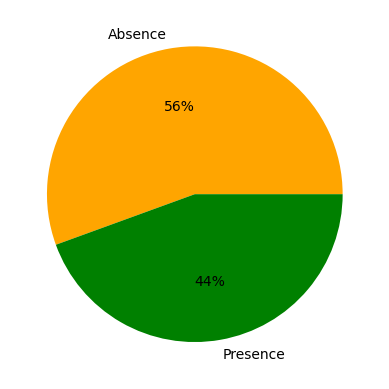

In [40]:
# To find the ratio between people who have disease or not 
Heart_Disease_Patients = heartds['Heart Disease'].value_counts()
colors = ['orange', 'green']
plt.pie(Heart_Disease_Patients.values,labels=Heart_Disease_Patients.index,autopct='%.0f%%',colors = colors)

In [41]:
#To find the ratio between Males and Females

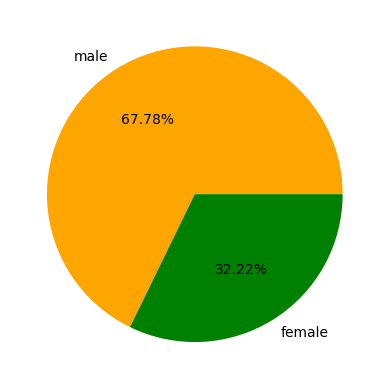

In [42]:
# ratio between Males and Famales 
Percent_MF = heartds['Sex'].value_counts()
colors = ['orange', 'green']
plt.pie(Percent_MF,labels = ['male','female'],autopct='%.2f%%',colors = colors)
plt.show()

In [43]:
#To find the blood vessels colored by fluroscopy

<BarContainer object of 4 artists>

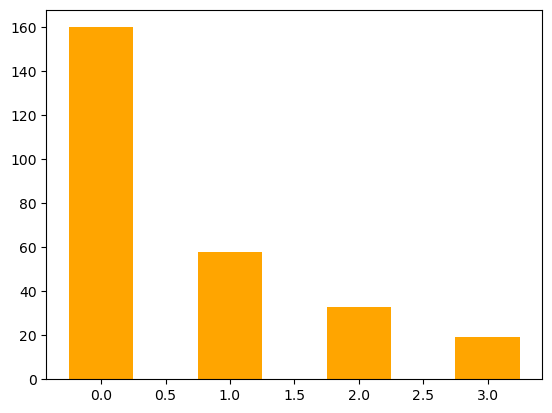

In [44]:
number_vessels_fluro = heartds['Number of vessels fluro'].value_counts()
plt.bar(
    x=number_vessels_fluro.index, 
    height=number_vessels_fluro.values,
    width=0.5,
    color='orange'
    # Adjust this value to control the bar width
)

In [45]:
#To check the analyis of count of patients and blood pressure

In [46]:
def draw_histogram_continuse_data(col_name):
    plt.hist(col_name,edgecolor='black',color='orange')
   

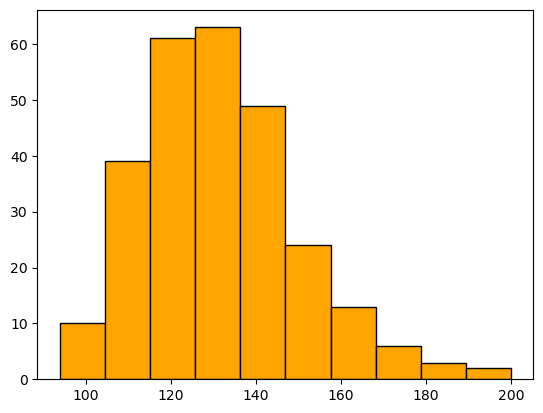

In [47]:
  draw_histogram_continuse_data(heartds['BP'])

In [48]:
#To check the analysis of count of patients and maximum hear rate

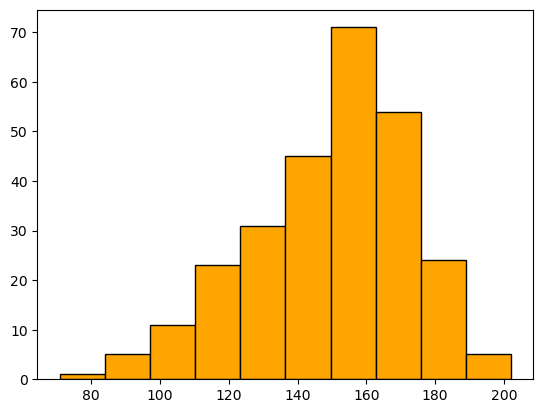

In [49]:
draw_histogram_continuse_data(heartds['Max HR'])

In [50]:
#To check the analysis of count of patients and chest pain type
#4 types of chest pain 
#Typical Angina(1)   Atypical Angina(2)   Non-anginal Pain(3)   Asymptomatic (No Chest Pain)(4)

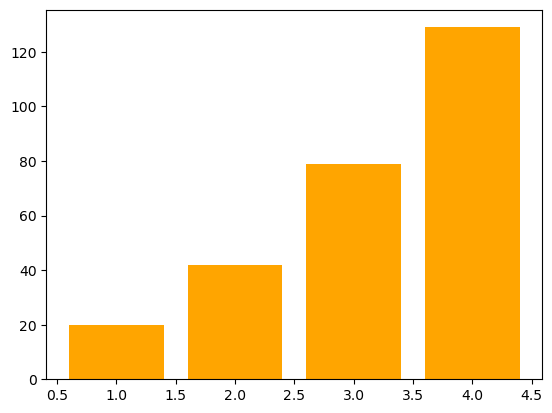

In [51]:
# fist one is the most dengure but it is raio very small 
chest_pain_type = heartds['Chest pain type'].value_counts()
plt.bar(x= chest_pain_type.index,height=chest_pain_type.values,color = 'orange')
plt.show()

In [52]:
#Here target is in character presence or absence .so we need to convert it into integer
#So Label encoder is used

In [53]:
heartds['Heart Disease'] = LabelEncoder().fit_transform(heartds['Heart Disease'])


In [54]:
heartds['Heart Disease'] 

0      1
1      0
2      1
3      0
4      0
      ..
265    0
266    0
267    0
268    0
269    1
Name: Heart Disease, Length: 270, dtype: int64

In [55]:
#To find corelation between variables

<AxesSubplot:>

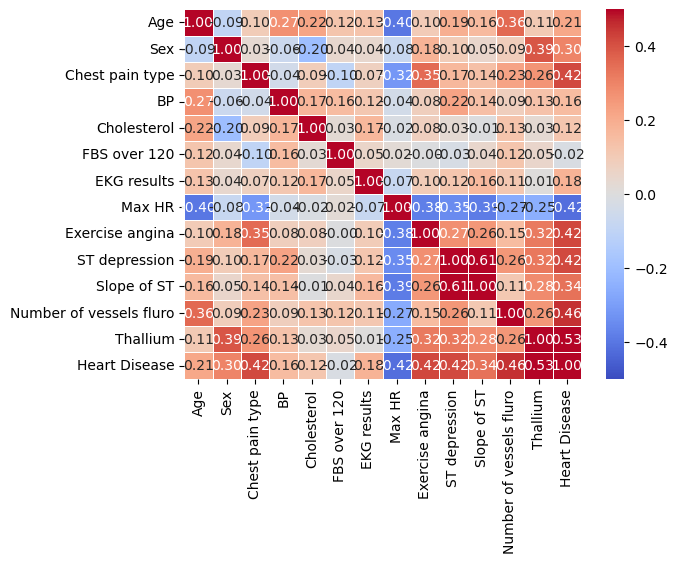

In [56]:
import seaborn as sns
corr = heartds.corr()
sns.heatmap(corr,cmap='coolwarm',annot= True,fmt = '.2f',linewidths=0.5, vmax=0.5,vmin=-0.5)

In [57]:
#Split Data into Features and Target

In [58]:
X = heartds.drop(['Heart Disease'], axis=1)
y = heartds['Heart Disease']

In [59]:
#Train-Test Split

In [60]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [61]:
#Standardize the Features

In [62]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [63]:
#Define the Models

In [64]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(probability=True, kernel="linear")
}


In [65]:
def evaluate_model(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    cm = confusion_matrix(y_test, y_pred)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1_score = report["1"]["f1-score"]
    
    return {
        "Accuracy": acc,
        "AUC": auc,
        "Confusion Matrix": cm,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
        "Model": model
    }


In [66]:
#Evaluate All Models

In [67]:
results = {}
for name, model in models.items():
    metrics = evaluate_model(model, x_train, y_train, x_test, y_test)
    results[name] = metrics


In [68]:
# Display the Results

In [69]:
for name, metrics in results.items():
    print(f"{name} Results:")
    print(f"Accuracy: {metrics['Accuracy']:.2f}")
    print(f"AUC-ROC: {metrics['AUC']}" if metrics['AUC'] != "N/A" else "")
    print(f"Precision: {metrics['Precision']:.2f}")
    print(f"Recall: {metrics['Recall']:.2f}")
    print(f"F1-Score: {metrics['F1-Score']:.2f}")
    print("Confusion Matrix:\n", metrics["Confusion Matrix"])
    print("-" * 50)


Logistic Regression Results:
Accuracy: 0.91
AUC-ROC: 0.9466089466089466
Precision: 0.90
Recall: 0.86
F1-Score: 0.88
Confusion Matrix:
 [[31  2]
 [ 3 18]]
--------------------------------------------------
Decision Tree Results:
Accuracy: 0.72
AUC-ROC: 0.7294372294372294
Precision: 0.62
Recall: 0.76
F1-Score: 0.68
Confusion Matrix:
 [[23 10]
 [ 5 16]]
--------------------------------------------------
Support Vector Machine Results:
Accuracy: 0.89
AUC-ROC: 0.9321789321789321
Precision: 0.89
Recall: 0.81
F1-Score: 0.85
Confusion Matrix:
 [[31  2]
 [ 4 17]]
--------------------------------------------------


In [70]:
#Plot ROC Curves

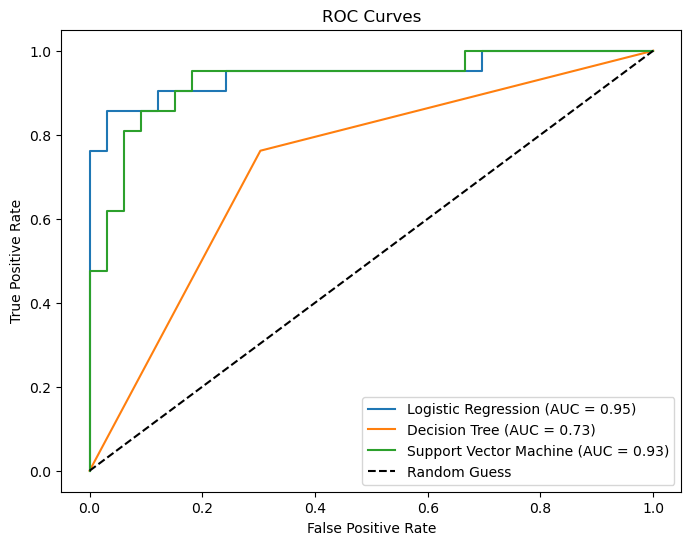

In [71]:
plt.figure(figsize=(8, 6))
for name, metrics in results.items():
    if metrics["AUC"] != "N/A":
        y_proba = metrics["Model"].predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [72]:
#We can improve recall and reduce false negatives

In [73]:
#1.Adjust class weights


In [74]:
from sklearn.model_selection import GridSearchCV

# Define Hyperparameter Grids
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "liblinear"]
    },
    "Decision Tree": {
        "criterion": ["gini", "entropy"],
        "max_depth": [3, 5, 10, None],
        "min_samples_split": [2, 5, 10]
    },
    "Support Vector Machine": {
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"]
    }
}


In [75]:
# Hyperparameter Tuning with GridSearchCV
def hyperparameter_tuning(model, params, x_train, y_train):
    grid = GridSearchCV(model, params, cv=5, scoring="accuracy", verbose=1)
    grid.fit(x_train, y_train)
    return grid.best_estimator_

In [76]:
# Updated Model Training with Hyperparameter Tuning
tuned_models = {}
for name, model in models.items():
    print(f"Tuning hyperparameters for {name}...")
    tuned_model = hyperparameter_tuning(model, param_grids[name], x_train, y_train)
    tuned_models[name] = tuned_model


Tuning hyperparameters for Logistic Regression...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Tuning hyperparameters for Decision Tree...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tuning hyperparameters for Support Vector Machine...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [77]:
# Evaluate Tuned Models
tuned_results = {}
for name, model in tuned_models.items():
    metrics = evaluate_model(model, x_train, y_train, x_test, y_test)
    tuned_results[name] = metrics

In [78]:
# Compare Before and After Tuning
print("\n--- Comparison of Before and After Hyperparameter Tuning ---\n")
for name in models.keys():
    print(f"{name} Before Tuning:")
    before = results[name]
    print(f"Accuracy: {before['Accuracy']:.2f}")
    print(f"AUC-ROC: {before['AUC']}" if before['AUC'] != "N/A" else "")
    print(f"Precision: {before['Precision']:.2f}")
    print(f"Recall: {before['Recall']:.2f}")
    print(f"F1-Score: {before['F1-Score']:.2f}")
    print("\n")
    
    print(f"{name} After Tuning:")
    after = tuned_results[name]
    print(f"Accuracy: {after['Accuracy']:.2f}")
    print(f"AUC-ROC: {after['AUC']}" if after['AUC'] != "N/A" else "")
    print(f"Precision: {after['Precision']:.2f}")
    print(f"Recall: {after['Recall']:.2f}")
    print(f"F1-Score: {after['F1-Score']:.2f}")
    print("-" * 50)


--- Comparison of Before and After Hyperparameter Tuning ---

Logistic Regression Before Tuning:
Accuracy: 0.91
AUC-ROC: 0.9466089466089466
Precision: 0.90
Recall: 0.86
F1-Score: 0.88


Logistic Regression After Tuning:
Accuracy: 0.89
AUC-ROC: 0.9278499278499278
Precision: 0.94
Recall: 0.76
F1-Score: 0.84
--------------------------------------------------
Decision Tree Before Tuning:
Accuracy: 0.72
AUC-ROC: 0.7294372294372294
Precision: 0.62
Recall: 0.76
F1-Score: 0.68


Decision Tree After Tuning:
Accuracy: 0.76
AUC-ROC: 0.8152958152958153
Precision: 0.68
Recall: 0.71
F1-Score: 0.70
--------------------------------------------------
Support Vector Machine Before Tuning:
Accuracy: 0.89
AUC-ROC: 0.9321789321789321
Precision: 0.89
Recall: 0.81
F1-Score: 0.85


Support Vector Machine After Tuning:
Accuracy: 0.89
AUC-ROC: 0.9292929292929293
Precision: 0.89
Recall: 0.81
F1-Score: 0.85
--------------------------------------------------


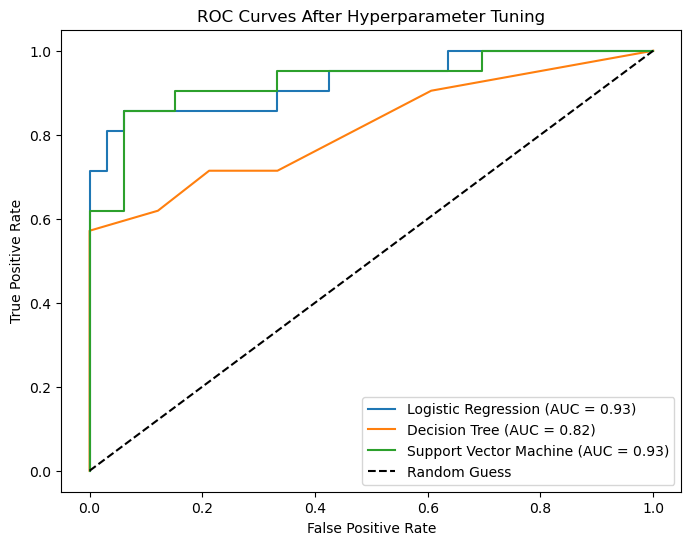

In [79]:
# Plot ROC Curves for Tuned Models
plt.figure(figsize=(8, 6))
for name, metrics in tuned_results.items():
    if metrics["AUC"] != "N/A":
        y_proba = metrics["Model"].predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves After Hyperparameter Tuning")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [80]:
# --- Data Preprocessing: Handling Class Imbalance using SMOTE ---
from imblearn.over_sampling import SMOTE

# Check the distribution of the target class
heartds['Heart Disease'].value_counts()


0    150
1    120
Name: Heart Disease, dtype: int64

In [81]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)


In [82]:
# Re-evaluate models with the new balanced dataset
# --- Re-defining models to include balanced training data ---
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(probability=True, kernel="linear")
}

In [83]:
# --- Hyperparameter Tuning with Cross-Validation ---
from sklearn.model_selection import cross_val_score

def evaluate_model_with_cv(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1] if hasattr(model, "predict_proba") else None

    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba) if y_proba is not None else "N/A"
    cm = confusion_matrix(y_test, y_pred)
    
    report = classification_report(y_test, y_pred, output_dict=True)
    precision = report["1"]["precision"]
    recall = report["1"]["recall"]
    f1_score = report["1"]["f1-score"]
    cross_val_acc = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy').mean()
    return {
        "Accuracy": acc,
        "AUC": auc,
        "Confusion Matrix": cm,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
        "Model": model,
        "Cross-Validation Accuracy": cross_val_acc
    }

In [84]:
# Cross-validation for better performance metrics

In [85]:
# Re-train the models with SMOTE data
results_smote = {}
for name, model in models.items():
    metrics = evaluate_model_with_cv(model, x_train_smote, y_train_smote, x_test, y_test)
    results_smote[name] = metrics


In [86]:
# --- Display Results After SMOTE and Cross-validation ---
for name, metrics in results_smote.items():
    print(f"{name} Results (After SMOTE and CV):")
    print(f"Accuracy: {metrics['Accuracy']:.2f}")
    print(f"AUC-ROC: {metrics['AUC']}" if metrics['AUC'] != "N/A" else "")
    print(f"Precision: {metrics['Precision']:.2f}")
    print(f"Recall: {metrics['Recall']:.2f}")
    print(f"F1-Score: {metrics['F1-Score']:.2f}")
    print(f"Cross-Validation Accuracy: {metrics['Cross-Validation Accuracy']:.2f}")
    print("Confusion Matrix:\n", metrics["Confusion Matrix"])
    print("-" * 50)

Logistic Regression Results (After SMOTE and CV):
Accuracy: 0.89
AUC-ROC: 0.9466089466089466
Precision: 0.86
Recall: 0.86
F1-Score: 0.86
Cross-Validation Accuracy: 0.82
Confusion Matrix:
 [[30  3]
 [ 3 18]]
--------------------------------------------------
Decision Tree Results (After SMOTE and CV):
Accuracy: 0.72
AUC-ROC: 0.712121212121212
Precision: 0.64
Recall: 0.67
F1-Score: 0.65
Cross-Validation Accuracy: 0.72
Confusion Matrix:
 [[25  8]
 [ 7 14]]
--------------------------------------------------
Support Vector Machine Results (After SMOTE and CV):
Accuracy: 0.85
AUC-ROC: 0.9292929292929293
Precision: 0.84
Recall: 0.76
F1-Score: 0.80
Cross-Validation Accuracy: 0.83
Confusion Matrix:
 [[30  3]
 [ 5 16]]
--------------------------------------------------


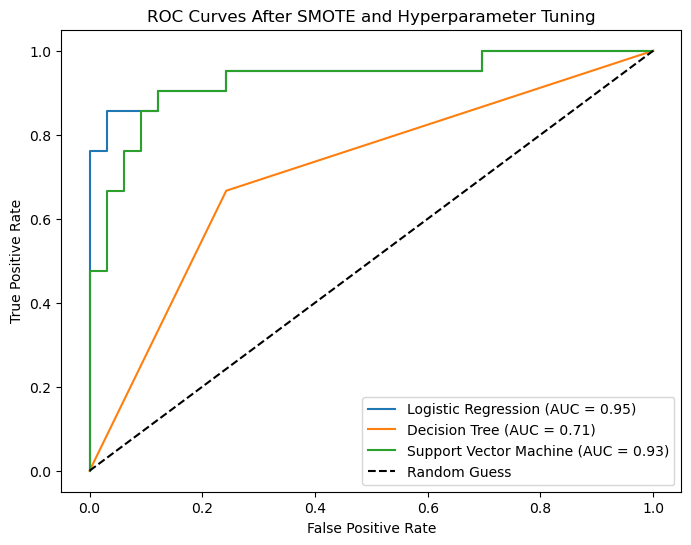

In [87]:
# --- Plot ROC Curves for All Models ---
plt.figure(figsize=(8, 6))
for name, metrics in results_smote.items():
    if metrics["AUC"] != "N/A":
        y_proba = metrics["Model"].predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves After SMOTE and Hyperparameter Tuning")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [88]:
# Tune models with updated parameter grids
def hyperparameter_tuning(model, params, x_train, y_train):
    grid = GridSearchCV(model, params, cv=5, scoring="accuracy", verbose=1, n_jobs=-1)
    grid.fit(x_train, y_train)
    return grid.best_estimator_


In [89]:
# Re-apply tuning with the balanced dataset
tuned_models_smote = {}
for name, model in models.items():
    print(f"Tuning hyperparameters for {name} with SMOTE data...")
    tuned_model = hyperparameter_tuning(model, param_grids[name], x_train_smote, y_train_smote)
    tuned_models_smote[name] = tuned_model

Tuning hyperparameters for Logistic Regression with SMOTE data...
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Tuning hyperparameters for Decision Tree with SMOTE data...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Tuning hyperparameters for Support Vector Machine with SMOTE data...
Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [90]:
# Evaluate the tuned models after SMOTE
tuned_results_smote = {}
for name, model in tuned_models_smote.items():
    metrics = evaluate_model_with_cv(model, x_train_smote, y_train_smote, x_test, y_test)
    tuned_results_smote[name] = metrics

In [91]:
# --- Display Results for Tuned Models ---
print("\n--- Results After Hyperparameter Tuning with SMOTE ---\n")
for name, metrics in tuned_results_smote.items():
    print(f"{name} After Tuning with SMOTE:")
    print(f"Accuracy: {metrics['Accuracy']:.2f}")
    print(f"AUC-ROC: {metrics['AUC']}" if metrics['AUC'] != "N/A" else "")
    print(f"Precision: {metrics['Precision']:.2f}")
    print(f"Recall: {metrics['Recall']:.2f}")
    print(f"F1-Score: {metrics['F1-Score']:.2f}")
    print(f"Cross-Validation Accuracy: {metrics['Cross-Validation Accuracy']:.2f}")
    print("-" * 50)


--- Results After Hyperparameter Tuning with SMOTE ---

Logistic Regression After Tuning with SMOTE:
Accuracy: 0.89
AUC-ROC: 0.9292929292929292
Precision: 0.94
Recall: 0.76
F1-Score: 0.84
Cross-Validation Accuracy: 0.84
--------------------------------------------------
Decision Tree After Tuning with SMOTE:
Accuracy: 0.74
AUC-ROC: 0.7113997113997113
Precision: 0.82
Recall: 0.43
F1-Score: 0.56
Cross-Validation Accuracy: 0.81
--------------------------------------------------
Support Vector Machine After Tuning with SMOTE:
Accuracy: 0.89
AUC-ROC: 0.9307359307359307
Precision: 0.89
Recall: 0.81
F1-Score: 0.85
Cross-Validation Accuracy: 0.84
--------------------------------------------------


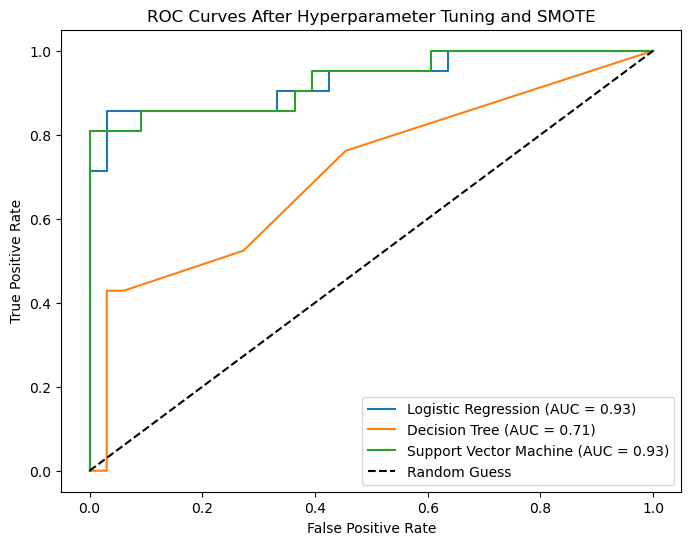

In [92]:
# --- ROC Curve for Tuned Models After SMOTE ---
plt.figure(figsize=(8, 6))
for name, metrics in tuned_results_smote.items():
    if metrics["AUC"] != "N/A":
        y_proba = metrics["Model"].predict_proba(x_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {metrics['AUC']:.2f})")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves After Hyperparameter Tuning and SMOTE")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()
